#PARCIAL 3, LIMPIEZA DE DATOS
##Profesor Gustavo Bruges, Analisis exploratorio de datos


In [277]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [278]:
df = pd.read_csv('https://raw.githubusercontent.com/Juan-Vega18/-ANALISIS-EXPLOR-DE-DATOS---63510/refs/heads/main/PARCIAL%203/prescripciones_raw_vega_jurado.csv')
df_copy = df.copy()

In [279]:
df

,id_paciente,fecha_prescripcion,medicamento,dosis_mg,via_administracion,diagnostico_cie10,peso_paciente_kg,edad,eps,prescriptor_id
0,4169,2024-11-12,METFORMINA,850.0,subcutanea,I10,81.558196,31.0,Sura,MED-2570
1,2830,mayo 7 2024,ASA,1000.0,Oral,NaN,69.083449,79.0,SANITAS,MED-3551
2,6220,2024-12-26,METFORMINA,850.0,Oral,hipertension,76.915534,51.0,COMPENSAR,MED-4311
3,3829,2023-08-23,Ibuprofeno,250.0,oral,E11,73.193337,46.0,EPS Sanitas,MED-2276
4,1695,2025-06-16,Metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989
...,...,...,...,...,...,...,...,...,...,...
515,5306,09/07/2025,ibuprofeno,NaN,SC,Z00.0,36.812128,35.0,EPS Sura,MED-5204
516,5331,07/01/2024,Aspirina,250.0,Intravenosa,K29.5,60.568806,NaN,Sanitas,MED-1648
517,3407,23/05/2025,ENALAPRIL,-1000.0,Subcutanea,J18.9,74.979641,24.0,Sanitas,MED-5394
518,1695,2025-06-16,Metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989


In [280]:
#Hacemos una revision completa del dataset para conocerlo.
print('*-'*50)
print(df.head())
print('*-'*50)
print(df.columns)
print('*-'*50)
print(df.isnull().sum())
print('*-'*50)
print(df.shape)
print('*-'*50)

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
   id_paciente fecha_prescripcion     medicamento dosis_mg via_administracion  \
0         4169         2024-11-12      METFORMINA    850.0         subcutanea   
1         2830        mayo 7 2024             ASA   1000.0               Oral   
2         6220         2024-12-26      METFORMINA    850.0               Oral   
3         3829         2023-08-23     Ibuprofeno     250.0               oral   
4         1695         2025-06-16  Metformina 500   1000.0               oral   

  diagnostico_cie10  peso_paciente_kg  edad          eps prescriptor_id  
0               I10         81.558196  31.0         Sura       MED-2570  
1               NaN         69.083449  79.0      SANITAS       MED-3551  
2      hipertension         76.915534  51.0    COMPENSAR       MED-4311  
3               E11         73.193337  46.0  EPS Sanitas       MED-2276  
4   diabetes tipo 2         62.946443   Na

Aquí tenemos la revisión de las características del dataset. encontramos que
tenemos 10 columnas, 5 de ellas tienen vacíos que vamos a revisar, así que empezaremos por orden.

In [281]:
print(df.describe()) #Tenemos solamente 3 columnas numericas
print('*-'*50)
print(df['diagnostico_cie10'].dtype)

       id_paciente  peso_paciente_kg        edad
count   520.000000        500.000000  502.000000
mean   5384.709615         67.777394   50.571713
std    2602.755459         28.472804   23.024109
min    1037.000000          2.000000   -1.000000
25%    2994.000000         57.900120   33.000000
50%    5319.500000         67.560773   51.000000
75%    7616.250000         76.430599   68.000000
max    9992.000000        450.000000  200.000000
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
object


In [282]:
#Modificamos los nombres de las columnas por minusculas:
df.colums = (
    df.columns.str.strip().str.lower().str.replace(" ", "_").str.encode('ascii', errors='ignore').str.decode('ascii')
)
print(df.columns.tolist())

['id_paciente', 'fecha_prescripcion', 'medicamento', 'dosis_mg', 'via_administracion', 'diagnostico_cie10', 'peso_paciente_kg', 'edad', 'eps', 'prescriptor_id']


/tmp/ipykernel_12894/1360268307.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.colums = (


#EMPEZAMOS CON ID PACIENTES

In [283]:
df['id_paciente']
print('*-'*50)
print(df['id_paciente'].isnull().sum()) #Lleno
print('*-'*50)
print(df['id_paciente'].nunique)
print('*-'*50)
print(df['id_paciente'].duplicated().sum())
print('*-'*50)
print(df['id_paciente'][df['id_paciente'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['id_paciente'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
0
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0      4169
1      2830
2      6220
3      3829
4      1695
       ... 
515    5306
516    5331
517    3407
518    1695
519    9963
Name: id_paciente, Length: 520, dtype: int64>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
43
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
6      1077
504    1077
387    1165
194    1165
315    1183
       ... 
186    9550
261    9722
514    9722
453    9963
519    9963
Name: id_paciente, Length: 83, dtype: int64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
id_paciente
8200    3
5306    3
5523    3
3164    2
5867    2
9963    2
4542    2
6135    2
8615 

Tenemos 83 id_paciente duplicados... aquí hay que decidir que hacer... vamos a asumir mientras que fueron prescripciones multiples en distintos periodos.

In [284]:
#MODIFICAMOS LA COLUMNA POR SI HAY ALGUN TEXTO:

id_paciente = (
    df['id_paciente']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas(si es preciso)
)

id_paciente = pd.to_numeric(id_paciente, errors='coerce') #Todo lo que no sea numerico se va a NaN
df['id_paciente'] = id_paciente

In [285]:
df['id_paciente']

,id_paciente
0,4169
1,2830
2,6220
3,3829
4,1695
...,...
515,5306
516,5331
517,3407
518,1695


#FECHA PRESCRIPCION

In [286]:
df['fecha_prescripcion']

,fecha_prescripcion
0,2024-11-12
1,mayo 7 2024
2,2024-12-26
3,2023-08-23
4,2025-06-16
...,...
515,09/07/2025
516,07/01/2024
517,23/05/2025
518,2025-06-16


In [287]:
#Tenemos fechas con letra y con numero... algunas separadas por espacios vacios, otras con '/' y otras con '-'
print('*-'*50)
print(df['fecha_prescripcion'].isnull().sum()) #Lleno
print('*-'*50)
print(df['fecha_prescripcion'].nunique)
print('*-'*50)
print(df['fecha_prescripcion'].duplicated().sum())
print('*-'*50)
print(df['fecha_prescripcion'][df['fecha_prescripcion'].duplicated(keep=False)].sort_values())

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
0
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0       2024-11-12
1      mayo 7 2024
2       2024-12-26
3       2023-08-23
4       2025-06-16
          ...     
515     09/07/2025
516     07/01/2024
517     23/05/2025
518     2025-06-16
519     2025-10-17
Name: fecha_prescripcion, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
65
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
294           07/01/2024
516           07/01/2024
13            09/07/2025
515           09/07/2025
69            19/05/2023
             ...        
256       febrero 9 2025
278        julio 25 2023
336        julio 25 2023
504    noviembre 18 2025
6      noviembre 18 2025
Name: fecha_pr

In [288]:
#Creamos un diccionario para reemplazar los meses con su correspondiente numerico
meses = {
    'enero':'01','febrero':'02','marzo':'03','abril':'04',
    'mayo':'05','junio':'06','julio':'07','agosto':'08',
    'septiembre':'09','octubre':'10','noviembre':'11','diciembre':'12'
}
df['fecha_prescripcion'] = df['fecha_prescripcion'].str.lower().str.strip().replace(meses, regex=True) #ya que lo hicimos, ahora simplemente aplicamos
#pd.datetime
df['fecha_prescripcion'] = pd.to_datetime(df['fecha_prescripcion'], format='mixed', errors='coerce')

In [289]:
df['fecha_prescripcion'].shape #No hemos perdido columnas todavia.
#convertimos fecha_prescripcion en 3 columnas separadas
df['fecha_prescripcion']

,fecha_prescripcion
0,2024-11-12
1,2024-05-07
2,2024-12-26
3,2023-08-23
4,2025-06-16
...,...
515,2025-09-07
516,2024-07-01
517,2025-05-23
518,2025-06-16


In [290]:
df['year'] = df['fecha_prescripcion'].dt.year #dividimos la fecha en nuevas columnas de año, semana y mes
df['week'] = df['fecha_prescripcion'].dt.weekday
df['month'] = df['fecha_prescripcion'].dt.month
df

,id_paciente,fecha_prescripcion,medicamento,dosis_mg,via_administracion,diagnostico_cie10,peso_paciente_kg,edad,eps,prescriptor_id,year,week,month
0,4169,2024-11-12,METFORMINA,850.0,subcutanea,I10,81.558196,31.0,Sura,MED-2570,2024,1,11
1,2830,2024-05-07,ASA,1000.0,Oral,NaN,69.083449,79.0,SANITAS,MED-3551,2024,1,5
2,6220,2024-12-26,METFORMINA,850.0,Oral,hipertension,76.915534,51.0,COMPENSAR,MED-4311,2024,3,12
3,3829,2023-08-23,Ibuprofeno,250.0,oral,E11,73.193337,46.0,EPS Sanitas,MED-2276,2023,2,8
4,1695,2025-06-16,Metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989,2025,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,5306,2025-09-07,ibuprofeno,NaN,SC,Z00.0,36.812128,35.0,EPS Sura,MED-5204,2025,6,9
516,5331,2024-07-01,Aspirina,250.0,Intravenosa,K29.5,60.568806,NaN,Sanitas,MED-1648,2024,0,7
517,3407,2025-05-23,ENALAPRIL,-1000.0,Subcutanea,J18.9,74.979641,24.0,Sanitas,MED-5394,2025,4,5
518,1695,2025-06-16,Metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989,2025,0,6


#Medicamento

In [291]:
df['medicamento']
#aplicamos cambios en el str
medicamento = (
    df['medicamento']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
)
df['medicamento'] = medicamento

In [292]:
df['medicamento'].unique()
#ácido acetilsalicílico, ampliamente conocido por su marca comercial, que es aspirina.
#entonces voy a optar por dejarlo como 2 categorías diferentes, una es la aspirina de la marca bayer,
# y la otra es cualquier aspirina.
#respecto a la metformina, hay dos categorías, metformina y metformina 500. Dado que es concentración del medicamento
# voy a optar tambien por dejarlos como dos categorías distintas, ya que si especifican la concentracion debe ser importante
df['medicamento']

,medicamento
0,metformina
1,asa
2,metformina
3,ibuprofeno
4,metformina 500
...,...
515,ibuprofeno
516,aspirina
517,enalapril
518,metformina 500


#dosis_mg

In [293]:
print('*-'*50)
print(df['dosis_mg'].isnull().sum()) #Lleno
print('*-'*50)
print(df['dosis_mg'].nunique)
print('*-'*50)
print(df['dosis_mg'].duplicated().sum())
print('*-'*50)
print(df['dosis_mg'][df['dosis_mg'].duplicated(keep=False)].sort_values())

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
31
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0        850.0
1       1000.0
2        850.0
3        250.0
4       1000.0
        ...   
515        NaN
516      250.0
517    -1000.0
518     1000.0
519      500.0
Name: dosis_mg, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
498
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
416    -1000.0
517    -1000.0
26     -1000.0
153    -1000.0
162    -1000.0
        ...   
459        NaN
471        NaN
489        NaN
498        NaN
515        NaN
Name: dosis_mg, Length: 514, dtype: object


In [294]:
df['dosis_mg'].unique()#revisamos los valores unios

array(['850.0', '1000.0', '250.0', nan, '-400.0', '400.0', '200.0',
       '500.0', '100.0', '850mg', '-1000.0', '250mg', '100mg', '50000.0',
       '-400mg', '500mg', '-250mg', '400mg', '200mg', '-100.0', '-200mg',
       '-200.0'], dtype=object)

In [295]:
#Resolvemos los mg primero
df['dosis_mg'] = df['dosis_mg'].str.replace('mg', '', regex=False).astype(float)

In [296]:
df['dosis_mg'].unique()

array([  850.,  1000.,   250.,    nan,  -400.,   400.,   200.,   500.,
         100., -1000., 50000.,  -250.,  -100.,  -200.])

In [297]:
dosis = (
    df['dosis_mg']
    .astype(str) #convertimos en float la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
    .str.replace(',','.',regex=False) #cambiamos comas por puntos (por si hay)
)

dosis_num = pd.to_numeric(dosis, errors='coerce') #Todo lo que no sea numerico se va a NaN
#eliminamos dosis negativas (no se si existan dosis negativas pero pues igual las quito, y tambien dosis imposibles)
dosis_num = dosis_num.where((dosis_num >0) & (dosis_num < 999999),np.nan)
df['dosis_mg'] = dosis_num

In [298]:
df['dosis_mg']

,dosis_mg
0,850.0
1,1000.0
2,850.0
3,250.0
4,1000.0
...,...
515,NaN
516,250.0
517,NaN
518,1000.0


In [299]:
df['dosis_mg'].unique()

array([  850.,  1000.,   250.,    nan,   400.,   200.,   500.,   100.,
       50000.])

#via_administracion

In [300]:
df['via_administracion']

,via_administracion
0,subcutanea
1,Oral
2,Oral
3,oral
4,oral
...,...
515,SC
516,Intravenosa
517,Subcutanea
518,oral


In [301]:
print('*-'*50)
print(df['via_administracion'].isnull().sum()) #Lleno
print('*-'*50)
print(df['via_administracion'].nunique)
print('*-'*50)
print(df['via_administracion'].duplicated().sum())
print('*-'*50)
print(df['via_administracion'][df['via_administracion'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['via_administracion'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
0
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0       subcutanea
1             Oral
2             Oral
3             oral
4             oral
          ...     
515             SC
516    Intravenosa
517     Subcutanea
518           oral
519     subcutanea
Name: via_administracion, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
510
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
417          IV
210          IV
363          IV
98           IV
65           IV
         ...   
244    via oral
454    via oral
252    via oral
149    via oral
259    via oral
Name: via_administracion, Length: 520, dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

In [302]:
#normalizamos texto

via_corr = (
    df['via_administracion']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
    .str.replace(',','.',regex=False) #cambiamos comas por puntos (por si hay)
)

df['via_administracion'] = via_corr

In [303]:
df['via_administracion'].unique() #Aqui tenemos varias categorias, vamos a crear un diccionario
vias = {
    'vo': 'oral',
    'via oral': 'oral',
    'sc': 'subcutanea',
    'iv': 'intravenosa'
}
df['via_administracion'] = df['via_administracion'].replace(vias)

In [304]:
df['via_administracion'].unique()

array(['subcutanea', 'oral', 'intravenosa'], dtype=object)

In [305]:
df['via_administracion']

,via_administracion
0,subcutanea
1,oral
2,oral
3,oral
4,oral
...,...
515,subcutanea
516,intravenosa
517,subcutanea
518,oral


#diagnostico_cie10

In [306]:
df['diagnostico_cie10']

,diagnostico_cie10
0,I10
1,NaN
2,hipertension
3,E11
4,diabetes tipo 2
...,...
515,Z00.0
516,K29.5
517,J18.9
518,diabetes tipo 2


In [307]:
print('*-'*50)
print(df['diagnostico_cie10'].isnull().sum()) #Tiene 98 vacios
print('*-'*50)
print(df['diagnostico_cie10'].nunique)
print('*-'*50)
print(df['diagnostico_cie10'].duplicated().sum())
print('*-'*50)
print(df['diagnostico_cie10'][df['diagnostico_cie10'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['diagnostico_cie10'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
98
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0                  I10
1                  NaN
2         hipertension
3                  E11
4      diabetes tipo 2
            ...       
515              Z00.0
516              K29.5
517              J18.9
518    diabetes tipo 2
519                E11
Name: diagnostico_cie10, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
511
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
519    E11
313    E11
338    E11
68     E11
339    E11
      ... 
493    NaN
498    NaN
503    NaN
504    NaN
514    NaN
Name: diagnostico_cie10, Length: 520, dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

In [308]:
df['diagnostico_cie10'].unique()

array(['I10', nan, 'hipertension', 'E11', 'diabetes tipo 2', 'J18.9',
       'Z00.0', 'J06.9', 'K29.5'], dtype=object)

Aquí encontramos algo interesante, esos codigos como I10, E11, J18.9 etc significan los codigos de diagnostico, en este caso, vamos a dejarlo en modo texto para estandarizarlos.

In [309]:
#Estandarizamos primero:

diag_corr = (
    df['diagnostico_cie10']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
    .str.replace(',','.',regex=False) #cambiamos comas por puntos (por si hay)
)
df['diagnostico_cie10'] = diag_corr
df['diagnostico_cie10'].unique()

array(['i10', 'nan', 'hipertension', 'e11', 'diabetes tipo 2', 'j18.9',
       'z00.0', 'j06.9', 'k29.5'], dtype=object)

In [310]:
#Creamos el diccionario
diagnosticos = {
    'i10': 'hipertension',
    'e11': 'diabetes tipo 2',
    'j18.9': 'neumonia',
    'z00.0': 'consulta general',
    'j06.9': 'infeccion respiratoria aguda',
    'k29.5': 'gastritis cronica'
}
df['diagnostico_cie10'] = df['diagnostico_cie10'].replace(diagnosticos)
df['diagnostico_cie10']

,diagnostico_cie10
0,hipertension
1,nan
2,hipertension
3,diabetes tipo 2
4,diabetes tipo 2
...,...
515,consulta general
516,gastritis cronica
517,neumonia
518,diabetes tipo 2


In [311]:
print(df['diagnostico_cie10'].unique()) #todas categorias llenas
print(df['diagnostico_cie10'].isnull().sum()) #lleno
print(df['diagnostico_cie10'].shape)

['hipertension' 'nan' 'diabetes tipo 2' 'neumonia' 'consulta general'
 'infeccion respiratoria aguda' 'gastritis cronica']
0
(520,)


#peso_paciente_kg

In [312]:
df['peso_paciente_kg']

,peso_paciente_kg
0,81.558196
1,69.083449
2,76.915534
3,73.193337
4,62.946443
...,...
515,36.812128
516,60.568806
517,74.979641
518,62.946443


In [313]:
print('*-'*50)
print(df['peso_paciente_kg'].isnull().sum()) #hay 20 vacios
print('*-'*50)
print(df['peso_paciente_kg'].nunique)
print('*-'*50)
print(df['peso_paciente_kg'].duplicated().sum())
print('*-'*50)
print(df['peso_paciente_kg'][df['peso_paciente_kg'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['peso_paciente_kg'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
20
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0      81.558196
1      69.083449
2      76.915534
3      73.193337
4      62.946443
         ...    
515    36.812128
516    60.568806
517    74.979641
518    62.946443
519    69.326138
Name: peso_paciente_kg, Length: 520, dtype: float64>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
46
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
28     3.0
107    3.0
109    3.0
228    3.0
313    3.0
      ... 
319    NaN
392    NaN
435    NaN
440    NaN
483    NaN
Name: peso_paciente_kg, Length: 69, dtype: float64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
peso_paciente_kg
nan                  

In [314]:
#df['peso_paciente_kg'].unique() #No tenemos valores en texto
#limpiamos y estandarizamos

peso_corr = (
    df['peso_paciente_kg']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
    .str.replace(',','.',regex=False) #cambiamos comas por puntos (por si hay)
)
peso_num = pd.to_numeric(peso_corr, errors='coerce') #Todo lo que no sea numerico se va a NaN
df['peso_paciente_kg'] = peso_num

In [315]:
df['peso_paciente_kg'].describe() #Tenemos pesos de 450 kg, y pesos minimos de 2 kg. Nosotros ahora no sabemos
#si el dataset incluye niños, entonces, dejaremos todos los pesos positivos, pero los mayores de 200 kg los vamos a reemplazar con np.nan
# dado que segun los plots lo que hay arriba de ese peso son outliers

,peso_paciente_kg
count,500.000000
mean,67.777394
std,28.472804
min,2.000000
25%,57.900120
50%,67.560773
75%,76.430599
max,450.000000


In [316]:
peso_num = peso_num.where((peso_num > 0)
& (peso_num <= 200), np.nan)
df['peso_paciente_kg'] = peso_num

In [317]:
df['peso_paciente_kg'].describe()

,peso_paciente_kg
count,498.000000
mean,66.242363
std,14.956535
min,2.000000
25%,57.894616
50%,67.449585
75%,76.349872
max,106.677037


Text(0.5, 1.0, 'Revisamos como estan distribuidos los datos')

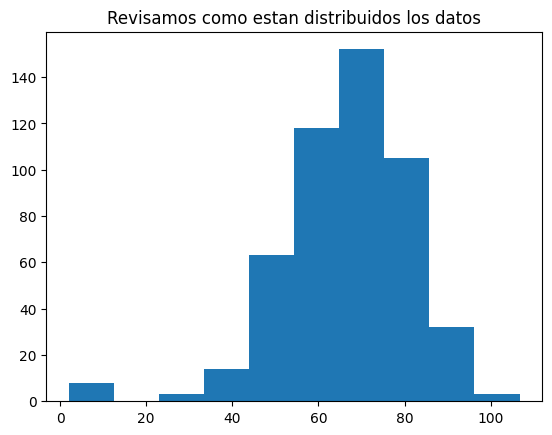

In [318]:
plt.hist(df['peso_paciente_kg'])
plt.title('Revisamos como estan distribuidos los datos')

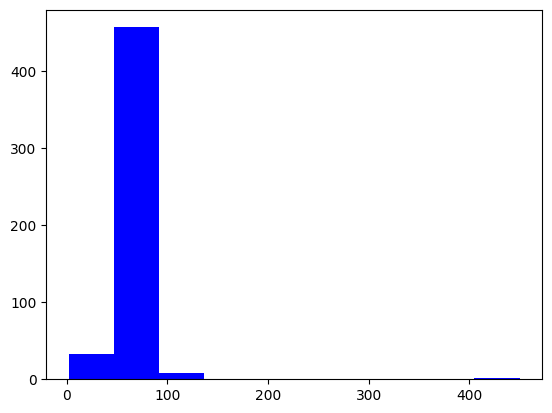

In [319]:
plt.hist(df_copy['peso_paciente_kg'], color='blue') #histograma original
plt.show()

Imputamos la media al peso de los pacientes con valores vacios

In [320]:
df['peso_paciente_kg'].fillna(df['peso_paciente_kg'].mean(), inplace=True) #dado que ya está limpio considero que es la mejor estrategia

/tmp/ipykernel_12894/2579841140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['peso_paciente_kg'].fillna(df['peso_paciente_kg'].mean(), inplace=True) #dado que ya está limpio considero que es la mejor estrategia


In [321]:
df

,id_paciente,fecha_prescripcion,medicamento,dosis_mg,via_administracion,diagnostico_cie10,peso_paciente_kg,edad,eps,prescriptor_id,year,week,month
0,4169,2024-11-12,metformina,850.0,subcutanea,hipertension,81.558196,31.0,Sura,MED-2570,2024,1,11
1,2830,2024-05-07,asa,1000.0,oral,nan,69.083449,79.0,SANITAS,MED-3551,2024,1,5
2,6220,2024-12-26,metformina,850.0,oral,hipertension,76.915534,51.0,COMPENSAR,MED-4311,2024,3,12
3,3829,2023-08-23,ibuprofeno,250.0,oral,diabetes tipo 2,73.193337,46.0,EPS Sanitas,MED-2276,2023,2,8
4,1695,2025-06-16,metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989,2025,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,5306,2025-09-07,ibuprofeno,NaN,subcutanea,consulta general,36.812128,35.0,EPS Sura,MED-5204,2025,6,9
516,5331,2024-07-01,aspirina,250.0,intravenosa,gastritis cronica,60.568806,NaN,Sanitas,MED-1648,2024,0,7
517,3407,2025-05-23,enalapril,NaN,subcutanea,neumonia,74.979641,24.0,Sanitas,MED-5394,2025,4,5
518,1695,2025-06-16,metformina 500,1000.0,oral,diabetes tipo 2,62.946443,NaN,Sanitas,MED-6989,2025,0,6


#EDAD

In [322]:
df['edad']

,edad
0,31.0
1,79.0
2,51.0
3,46.0
4,NaN
...,...
515,35.0
516,NaN
517,24.0
518,NaN


In [323]:
print('*-'*50)
print(df['edad'].isnull().sum()) #Tiene 18 vacios
print('*-'*50)
print(df['edad'].nunique)
print('*-'*50)
print(df['edad'].duplicated().sum())
print('*-'*50)
print(df['edad'][df['edad'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['edad'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
18
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0      31.0
1      79.0
2      51.0
3      46.0
4       NaN
       ... 
515    35.0
516     NaN
517    24.0
518     NaN
519    72.0
Name: edad, Length: 520, dtype: float64>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
449
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
398    0.0
84     0.0
406    0.0
256    0.0
500    0.0
      ... 
430    NaN
466    NaN
508    NaN
516    NaN
518    NaN
Name: edad, Length: 519, dtype: float64
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
edad
nan     18
70.0    16
73.0    14
40.0    13
56.0    13
54.0    12
83.0    12
35.0    11
53.0    11
26.0    11


In [324]:
df['edad'].unique() #no tenemos valores texuales

array([ 31.,  79.,  51.,  46.,  nan,  23.,  27.,  58.,  76.,  77.,  70.,
        72.,  57.,  35.,  24.,  20.,  26.,  39.,  45.,  50.,  54.,  47.,
        40.,  84.,  62.,  19.,  53.,  25.,  52.,  48.,  60.,  75.,  30.,
        56.,  29.,  83.,  81.,  41.,  38.,  59.,  69.,  78.,  49.,  28.,
        82.,  32.,   0.,  61.,  55.,  71.,  36.,  22.,  67.,  80.,  65.,
       200.,  63.,  64.,  18.,  34.,  44.,  33.,  21.,  74.,  37.,  73.,
        68.,  66.,  42.,  -1.,  43.])

,edad
count,502.000000
mean,50.571713
std,23.024109
min,-1.000000
25%,33.000000
50%,51.000000
75%,68.000000
max,200.000000


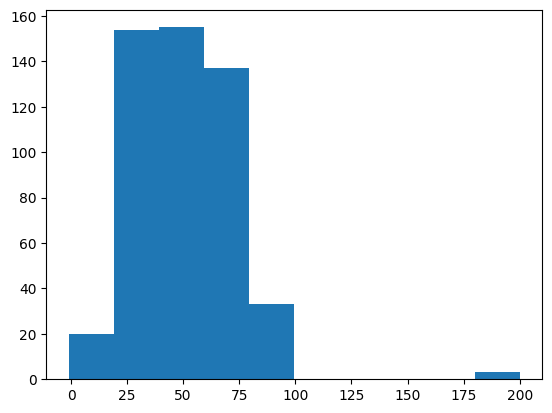

In [325]:
plt.hist(df['edad']) #tenemos un grupo de outliers, yo voy a dejar las edades menores a 120 años
df['edad'].describe()

In [326]:
#estandarizamos
edad_corr = (
    df['edad']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (por si hay numeros en escrito)
    .str.replace(',','.',regex=False) #cambiamos comas por puntos (por si hay)
)
edad_num = pd.to_numeric(edad_corr, errors='coerce') #Todo lo que no sea numerico se va a NaN
edad_num = edad_num.where((edad_num > 0)
& (edad_num <= 120), np.nan)
df['edad'] = edad_num

In [327]:
#Vamos a imputar la edad
df['edad'].fillna(df['edad'].mean(), inplace=True)# vamos a imputar con la media porque ya despues de haber limpiado el dataset
#ya no tenemos valores extremos que extremicen los valores reales.

/tmp/ipykernel_12894/3177447554.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['edad'].fillna(df['edad'].mean(), inplace=True)# vamos a imputar con la media porque ya despues de haber limpiado el dataset


(array([54., 58., 40., 52., 66., 64., 44., 43., 57., 42.]),
 array([18. , 24.6, 31.2, 37.8, 44.4, 51. , 57.6, 64.2, 70.8, 77.4, 84. ]),
 <BarContainer object of 10 artists>)

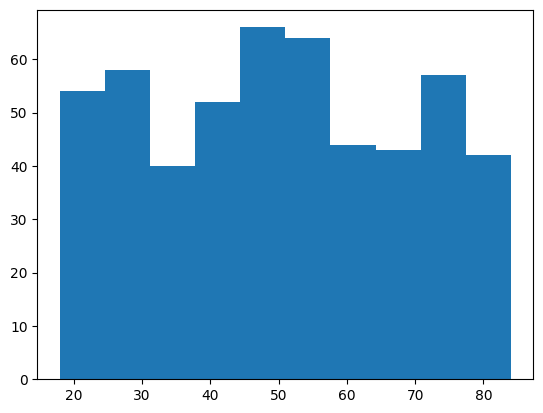

In [328]:
df['edad'].describe()
plt.hist(df['edad'])

resolvamos estas categorias:
pediátrico (<18),
adulto (18-64),
adulto mayor (>=65).

In [329]:
df['grupo_etario'] = pd.cut(df['edad'],
    bins=[0, 17, 64, float('inf')],
    labels=['pediatrico', 'adulto', 'adulto mayor'])

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_paciente         520 non-null    int64         
 1   fecha_prescripcion  520 non-null    datetime64[ns]
 2   medicamento         520 non-null    object        
 3   dosis_mg            475 non-null    float64       
 4   via_administracion  520 non-null    object        
 5   diagnostico_cie10   520 non-null    object        
 6   peso_paciente_kg    520 non-null    float64       
 7   edad                520 non-null    float64       
 8   eps                 520 non-null    object        
 9   prescriptor_id      477 non-null    object        
 10  year                520 non-null    int32         
 11  week                520 non-null    int32         
 12  month               520 non-null    int32         
 13  grupo_etario        520 non-null    category      

#EPS

In [331]:
df['eps']

,eps
0,Sura
1,SANITAS
2,COMPENSAR
3,EPS Sanitas
4,Sanitas
...,...
515,EPS Sura
516,Sanitas
517,Sanitas
518,Sanitas


In [332]:
print('*-'*50)
print(df['eps'].isnull().sum()) #está lleno
print('*-'*50)
print(df['eps'].nunique)
print('*-'*50)
print(df['eps'].duplicated().sum())
print('*-'*50)
print(df['eps'][df['eps'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['eps'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
0
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0             Sura
1          SANITAS
2        COMPENSAR
3      EPS Sanitas
4          Sanitas
          ...     
515       EPS Sura
516        Sanitas
517        Sanitas
518        Sanitas
519       EPS Sura
Name: eps, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
509
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
151    COMPENSAR
115    COMPENSAR
30     COMPENSAR
455    COMPENSAR
379    COMPENSAR
         ...    
49     nueva eps
281    nueva eps
131    nueva eps
285    nueva eps
448    nueva eps
Name: eps, Length: 520, dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-

In [333]:
df['eps'].unique()

array(['Sura', 'SANITAS', 'COMPENSAR', 'EPS Sanitas', 'Sanitas',
       'EPS Sura', 'Compensar', 'Nueva EPS', 'SURA', 'NuevaEPS',
       'nueva eps'], dtype=object)

In [334]:
#estandarizamos

eps_corr = (
    df['eps']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
)

df['eps'] = eps_corr

In [335]:
df['eps'].unique() #Aqui creamos un diccionario para mantener las categorias

array(['sura', 'sanitas', 'compensar', 'eps sanitas', 'eps sura',
       'nueva eps', 'nuevaeps'], dtype=object)

In [336]:
eps = {
    'eps sanitas': 'sanitas',
    'eps sura': 'sura',
    'nuevaeps': 'nueva eps'
}
df['eps'] = df['eps'].replace(eps)
df['eps'].unique()

array(['sura', 'sanitas', 'compensar', 'nueva eps'], dtype=object)

#prescriptor_id

In [337]:
df['prescriptor_id']

,prescriptor_id
0,MED-2570
1,MED-3551
2,MED-4311
3,MED-2276
4,MED-6989
...,...
515,MED-5204
516,MED-1648
517,MED-5394
518,MED-6989


In [338]:
print('*-'*50)
print(df['prescriptor_id'].isnull().sum()) #tiene 43 vacios
print('*-'*50)
print(df['prescriptor_id'].nunique)
print('*-'*50)
print(df['prescriptor_id'].duplicated().sum())
print('*-'*50)
print(df['prescriptor_id'][df['prescriptor_id'].duplicated(keep=False)].sort_values())
print('*-'*50)
print(df_copy['prescriptor_id'].astype(str).str.strip().value_counts().head(30))

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
43
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
<bound method IndexOpsMixin.nunique of 0      MED-2570
1      MED-3551
2      MED-4311
3      MED-2276
4      MED-6989
         ...   
515    MED-5204
516    MED-1648
517    MED-5394
518    MED-6989
519    MED-8840
Name: prescriptor_id, Length: 520, dtype: object>
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
67
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
510    MED-0161
25     MED-0161
131    MED-0392
352    MED-0392
294    MED-1648
         ...   
477         NaN
481         NaN
495         NaN
497         NaN
509         NaN
Name: prescriptor_id, Length: 92, dtype: object
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


In [339]:
df['prescriptor_id'].unique()
df['prescriptor_id'].shape

(520,)

In [340]:
#vamos a estandarizar, quitarle los tipicos errores comunes
prescriptor_corr = (
    df['prescriptor_id']
    .astype(str) #convertimos en str la column
    .str.strip() #quitamos espacios vacios antes y despues
    .str.lower() #convertimos a minusculas (dado que hay numeros en escrito)
    .str.replace(',','-',regex=False) #cambiamos comas por guiones
    .str.replace(' ','-', regex=False) #cambiamos los espacios vacios por guiones
    .str.replace('.','-', regex=False)
)

df['prescriptor_id'] = prescriptor_corr
df['prescriptor_id']

,prescriptor_id
0,med-2570
1,med-3551
2,med-4311
3,med-2276
4,med-6989
...,...
515,med-5204
516,med-1648
517,med-5394
518,med-6989


In [341]:
df['prescriptor_id'].shape

(520,)

#REVISAMOS QUE OBTUVIMOS

In [342]:
df

,id_paciente,fecha_prescripcion,medicamento,dosis_mg,via_administracion,diagnostico_cie10,peso_paciente_kg,edad,eps,prescriptor_id,year,week,month,grupo_etario
0,4169,2024-11-12,metformina,850.0,subcutanea,hipertension,81.558196,31.000000,sura,med-2570,2024,1,11,adulto
1,2830,2024-05-07,asa,1000.0,oral,nan,69.083449,79.000000,sanitas,med-3551,2024,1,5,adulto mayor
2,6220,2024-12-26,metformina,850.0,oral,hipertension,76.915534,51.000000,compensar,med-4311,2024,3,12,adulto
3,3829,2023-08-23,ibuprofeno,250.0,oral,diabetes tipo 2,73.193337,46.000000,sanitas,med-2276,2023,2,8,adulto
4,1695,2025-06-16,metformina 500,1000.0,oral,diabetes tipo 2,62.946443,50.279919,sanitas,med-6989,2025,0,6,adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,5306,2025-09-07,ibuprofeno,NaN,subcutanea,consulta general,36.812128,35.000000,sura,med-5204,2025,6,9,adulto
516,5331,2024-07-01,aspirina,250.0,intravenosa,gastritis cronica,60.568806,50.279919,sanitas,med-1648,2024,0,7,adulto
517,3407,2025-05-23,enalapril,NaN,subcutanea,neumonia,74.979641,24.000000,sanitas,med-5394,2025,4,5,adulto
518,1695,2025-06-16,metformina 500,1000.0,oral,diabetes tipo 2,62.946443,50.279919,sanitas,med-6989,2025,0,6,adulto


In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_paciente         520 non-null    int64         
 1   fecha_prescripcion  520 non-null    datetime64[ns]
 2   medicamento         520 non-null    object        
 3   dosis_mg            475 non-null    float64       
 4   via_administracion  520 non-null    object        
 5   diagnostico_cie10   520 non-null    object        
 6   peso_paciente_kg    520 non-null    float64       
 7   edad                520 non-null    float64       
 8   eps                 520 non-null    object        
 9   prescriptor_id      520 non-null    object        
 10  year                520 non-null    int32         
 11  week                520 non-null    int32         
 12  month               520 non-null    int32         
 13  grupo_etario        520 non-null    category      

In [344]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_paciente         520 non-null    int64  
 1   fecha_prescripcion  520 non-null    object 
 2   medicamento         520 non-null    object 
 3   dosis_mg            489 non-null    object 
 4   via_administracion  520 non-null    object 
 5   diagnostico_cie10   422 non-null    object 
 6   peso_paciente_kg    500 non-null    float64
 7   edad                502 non-null    float64
 8   eps                 520 non-null    object 
 9   prescriptor_id      477 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 40.8+ KB


#DECISION CON LOS NaN
Depsues de haber hecho toda la limpieza unicamente la columna dosis_mg nos quedó con algunos valores faltantes, nosotros podriamos decidir un monton de cosas sobre esos valores por en este trabajo no los voy a llenar porque desconzco las estrategias para este tipo en especifico de datos faltantes. en todo caso, podriamos borrarlos dado que una prescripcion sin dosis de medicamento NO es una buena prescripcion, al menos, como yo lo veo, aparte de que es inseguro para el paciente, en la vida real segun mi conocimiento no tiene mucho sentido. asi que vamos a meter un dropna.

In [349]:
df.dropna(subset=['dosis_mg'], inplace=True)

In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475 entries, 0 to 519
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_paciente         475 non-null    int64         
 1   fecha_prescripcion  475 non-null    datetime64[ns]
 2   medicamento         475 non-null    object        
 3   dosis_mg            475 non-null    float64       
 4   via_administracion  475 non-null    object        
 5   diagnostico_cie10   475 non-null    object        
 6   peso_paciente_kg    475 non-null    float64       
 7   edad                475 non-null    float64       
 8   eps                 475 non-null    object        
 9   prescriptor_id      475 non-null    object        
 10  year                475 non-null    int32         
 11  week                475 non-null    int32         
 12  month               475 non-null    int32         
 13  grupo_etario        475 non-null    category      
dtyp

#RESUMEN DEL TRABAJO

In [351]:
resumen = (df.groupby(['eps', 'via_administracion'])['dosis_mg']
    .agg(conteo='count', media='mean', std='std', minimo='min', maximo='max')
    .round(2)
    .reset_index()
)

print("=== RESUMEN POR EPS Y VÍA DE ADMINISTRACIÓN ===\n")
print(resumen.to_string(index=False))

print(f"\n=== COMPARACIÓN DATASET ===")
print(f"Filas originales:  {len(df_copy)}")
print(f"Filas limpias:     {len(df)}")
print(f"Filas eliminadas:  {len(df_copy) - len(df)}")
print(f"Columnas originales: {df_copy.shape[1]}")
print(f"Columnas finales:    {df.shape[1]}")

=== RESUMEN POR EPS Y VÍA DE ADMINISTRACIÓN ===

      eps via_administracion  conteo   media      std  minimo  maximo
compensar        intravenosa      19  442.11   305.62   100.0  1000.0
compensar               oral      39  560.26   366.02   100.0  1000.0
compensar         subcutanea      27  481.48   337.74   100.0  1000.0
nueva eps        intravenosa      29  544.83   313.49   100.0  1000.0
nueva eps               oral      51 1403.92  6947.33   100.0 50000.0
nueva eps         subcutanea      42 1635.71  7651.27   100.0 50000.0
  sanitas        intravenosa      47  476.60   332.78   100.0  1000.0
  sanitas               oral      50  492.00   321.88   100.0  1000.0
  sanitas         subcutanea      27  503.70   314.38   100.0  1000.0
     sura        intravenosa      47 2552.13 10114.82   100.0 50000.0
     sura               oral      53  464.15   314.15   100.0  1000.0
     sura         subcutanea      44 1654.55  7464.41   100.0 50000.0

=== COMPARACIÓN DATASET ===
Filas origin

#Guardar

In [352]:
df.to_csv('prescripciones_limpias_[VEGA-JURADO].csv', index=False)